<a href="https://colab.research.google.com/github/AbimaelDD/code/blob/main/multi_class_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from keras import layers, models
from keras.datasets import reuters


In [6]:
(train_data, train_labels), (test_data, test_labels) =reuters.load_data(num_words=10000)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
train_data[0]

[1,
 2,
 2,
 8,
 43,
 10,
 447,
 5,
 25,
 207,
 270,
 5,
 3095,
 111,
 16,
 369,
 186,
 90,
 67,
 7,
 89,
 5,
 19,
 102,
 6,
 19,
 124,
 15,
 90,
 67,
 84,
 22,
 482,
 26,
 7,
 48,
 4,
 49,
 8,
 864,
 39,
 209,
 154,
 6,
 151,
 6,
 83,
 11,
 15,
 22,
 155,
 11,
 15,
 7,
 48,
 9,
 4579,
 1005,
 504,
 6,
 258,
 6,
 272,
 11,
 15,
 22,
 134,
 44,
 11,
 15,
 16,
 8,
 197,
 1245,
 90,
 67,
 52,
 29,
 209,
 30,
 32,
 132,
 6,
 109,
 15,
 17,
 12]

In [8]:
word_index = reuters.get_word_index()
word_index = dict([(value, key) for (key, value) in word_index.items()])

for _ in train_data[0]:
  print(word_index.get(_ - 3))

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
None
None
None
said
as
a
result
of
its
december
acquisition
of
space
co
it
expects
earnings
per
share
in
1987
of
1
15
to
1
30
dlrs
per
share
up
from
70
cts
in
1986
the
company
said
pretax
net
should
rise
to
nine
to
10
mln
dlrs
from
six
mln
dlrs
in
1986
and
rental
operation
revenues
to
19
to
22
mln
dlrs
from
12
5
mln
dlrs
it
said
cash
flow
per
share
this
year
should
be
2
50
to
three
dlrs
reuter
3


In [9]:
train_labels[0]

np.int64(3)

In [10]:
train_data.shape

(8982,)

In [11]:
import numpy as np

In [12]:
def vectorizar(sequences, dimension=10000):
  results = np.zeros((len(sequences), dimension))
  for i, sequences in enumerate(sequences):
    results[i, sequences] = 1
  return results

In [13]:
x_train = vectorizar(train_data)
x_test = vectorizar(test_data)

from keras.utils import to_categorical

y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

In [14]:
modelo = models.Sequential()
modelo.add(layers.Dense(64, activation='relu', input_shape=(10000,)))
modelo.add(layers.Dense(64, activation='relu'))
modelo.add(layers.Dense(46, activation='softmax'))

modelo.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
modelo.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       640,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 46)             │         2,990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 647,214 (2.47 MB)

 Trainable params: 647,214 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
x_val = x_train[:1000]
partial_x_train =x_train[1000:]

y_val = y_train[:1000]
partial_y_train = y_train[1000:]

In [17]:
history = modelo.fit(partial_x_train, partial_y_train, epochs=30, batch_size=512, validation_data=(x_val,y_val))

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.4139 - loss: 3.2158 - val_accuracy: 0.6360 - val_loss: 1.7625
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.6803 - loss: 1.5786 - val_accuracy: 0.7110 - val_loss: 1.3325
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.7412 - loss: 1.1909 - val_accuracy: 0.7570 - val_loss: 1.1770
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.7954 - loss: 0.9588 - val_accuracy: 0.7510 - val_loss: 1.0952
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.8275 - loss: 0.7910 - val_accuracy: 0.7910 - val_loss: 1.0127
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.8530 - loss: 0.6989 - val_accuracy: 0.8050 - val_loss: 0.9597
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8745 - loss: 0.5780 - val_accuracy: 0.8080 - val_loss: 0.9336
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.8958 - loss: 0.4934 - val_accuracy: 0.8130 - 

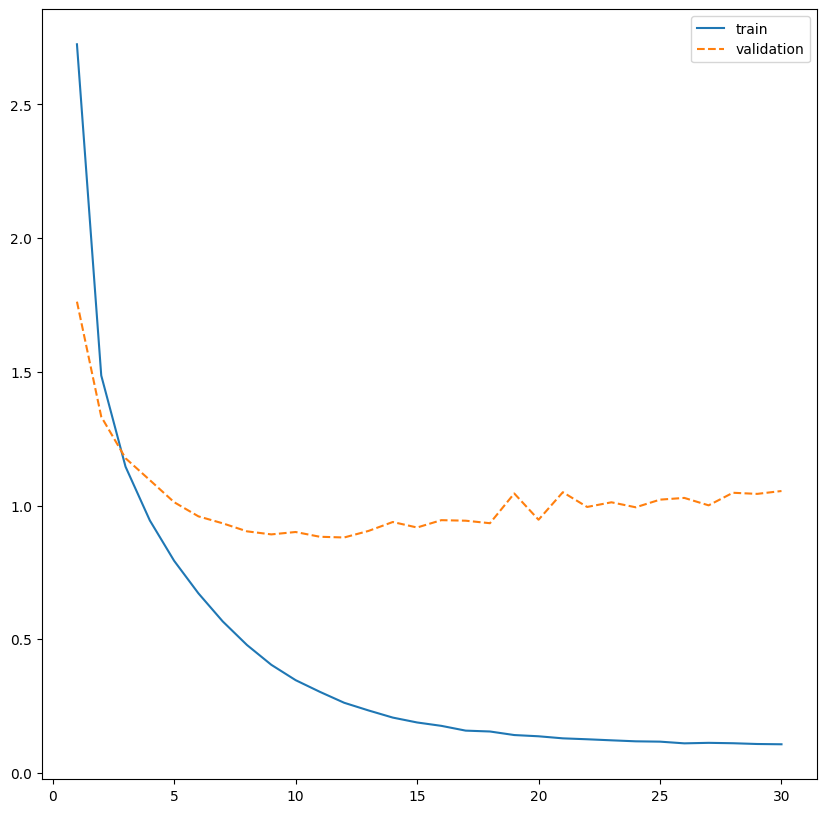

In [19]:
history_dict =history.history

loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,10))
epoch = range(1, len(loss_values)+1)

plt.plot(epoch, loss_values, '-', label='train')
plt.plot(epoch, val_loss_values, '--', label='validation')
plt.legend()
plt.show()

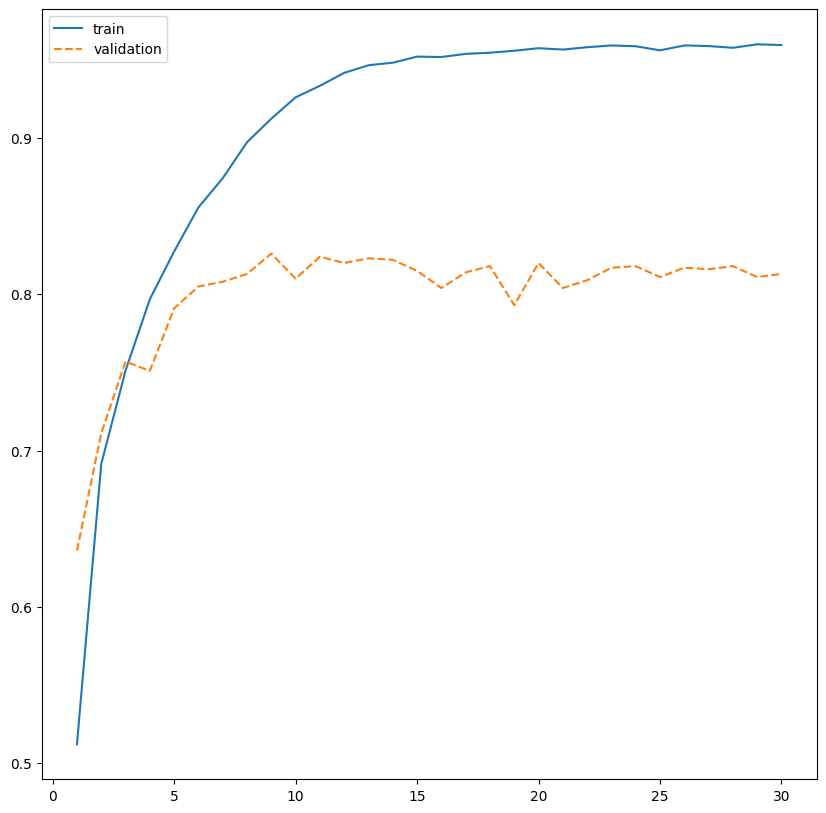

In [20]:
history_dict =history.history

loss_values = history_dict['accuracy']
val_loss_values = history_dict['val_accuracy']

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,10))
epoch = range(1, len(loss_values)+1)

plt.plot(epoch, loss_values, '-', label='train')
plt.plot(epoch, val_loss_values, '--', label='validation')
plt.legend()
plt.show()

In [21]:
predictions = modelo.predict(x_test)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [22]:
predictions[0]

array([1.54481867e-08, 2.50683911e-07, 2.14742460e-12, 9.99249578e-01,
       5.24237752e-04, 3.02096281e-09, 9.40961961e-11, 1.54185447e-08,
       5.11149919e-05, 8.41553458e-07, 8.20134094e-09, 5.41775016e-08,
       4.24254907e-08, 5.94401506e-09, 1.13011644e-08, 5.86039572e-09,
       2.34656824e-07, 4.50194881e-10, 3.19954840e-09, 5.07157392e-06,
       1.60277370e-04, 2.58981981e-06, 1.12249550e-10, 1.59406035e-08,
       1.13176455e-08, 1.11469378e-09, 9.83475523e-10, 1.49766592e-07,
       8.54501607e-08, 2.93030553e-07, 1.84620404e-07, 3.90949850e-09,
       1.33108458e-08, 2.29903407e-09, 2.18185050e-07, 2.18967355e-09,
       4.61185391e-06, 7.41230688e-12, 9.88271895e-11, 1.52158307e-07,
       7.58466800e-09, 3.28452785e-08, 2.09018122e-10, 1.15828751e-08,
       2.91095828e-11, 5.68540354e-12], dtype=float32)

In [23]:
np.sum(predictions[0])

np.float32(1.0000001)

In [24]:
np.argmax(predictions[0])

np.int64(3)

In [26]:
modelo.evaluate(x_train,y_train)

281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9142 - loss: 0.4238


[0.18908558785915375, 0.9505677819252014]

# Agregar tamaño de las capas ocultas, regularización y dropout